# ЛР 3.1: Полиномиальные модели

## Теоретическая часть

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
import time


metrics = []
data = pd.read_csv("./data/gen_regression.csv")
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


### Разделим данные и визуализируем их

In [187]:
X = data.x
y = data.y

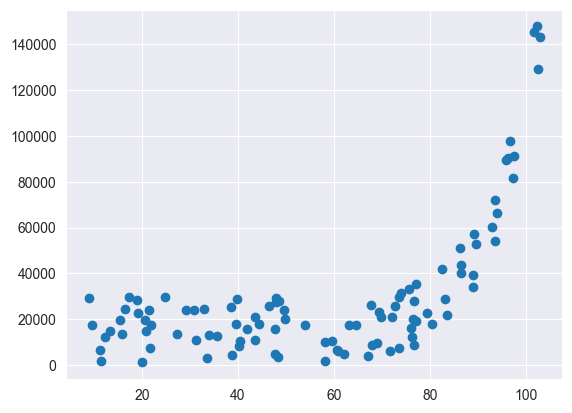

In [188]:
plt.scatter(X, y)

### Создадим модель и сразу обучим

In [189]:
X = pd.DataFrame(X) # Преобразуем сразу в двумерный массив для обучения

start_time = time.time()  # старт таймера

linear = LinearRegression().fit(X, y)

end_time = time.time()    # конец таймера
t_reg_lin = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_reg_lin, " сек.")

Время обучения модели:  0.0011217594146728516  сек.


### Смотрим нашу модель на полигоне точек

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


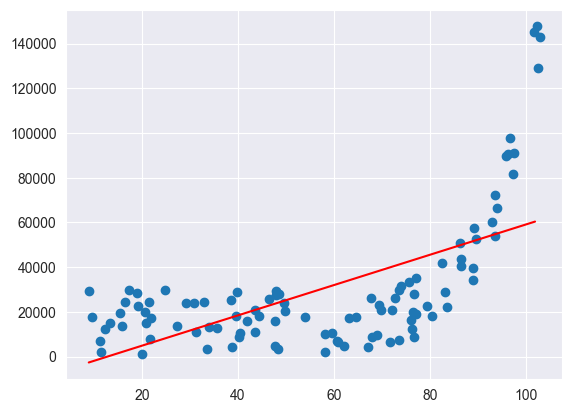

In [190]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

### Метрики модели

In [191]:
print("R2 = ", linear.score(X, y))
metrics.append(linear.score(X, y))

R2 =  0.37467360318911636


### Преобразование в полиномиальную модель и обучение

In [192]:
transformation = PolynomialFeatures(degree=2) # Полином 2 степени
transformation.fit(X)
X_2 = transformation.transform(X) # Преобразуем датасет X для полинома

print(X_2.shape)
X_2[:5]

(100, 3)


array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

### Обучение второй модели по обновленному датасету

In [193]:
start_time = time.time()  # старт таймера

poly_2d = LinearRegression().fit(X_2, y)

end_time = time.time()    # конец таймера
t_reg_poly2 = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_reg_poly2, " сек.")
xx_2d = transformation.transform(pd.DataFrame(xx))

Время обучения модели:  0.0009272098541259766  сек.


C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


### Визуализируем

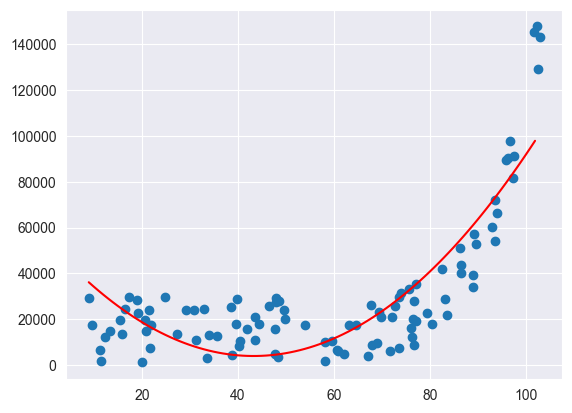

In [194]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

### Метрики

In [195]:
print("R2 = ", poly_2d.score(X_2, y))
metrics.append(poly_2d.score(X_2, y))

R2 =  0.7359753787024842


### ================ Классификация ================

In [196]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv", index_col=0)
y = data.y
X = data.drop(["y"], axis=1)

### Данные на графике

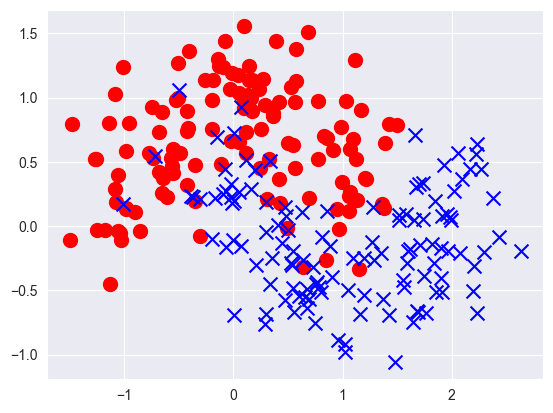

In [197]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

### Создание и сразу обучение модели

In [198]:
start_time = time.time()  # старт таймера

logistic = LogisticRegression().fit(X, y)

end_time = time.time()    # конец таймера
t_class_lin = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_class_lin, " сек.")

Время обучения модели:  0.00410008430480957  сек.


### Визуализируем модель на значениях

C:\Users\Bush\AppData\Local\Temp\ipykernel_17968\4167178149.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
C:\Users\Bush\AppData\Local\Temp\ipykernel_17968\4167178149.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


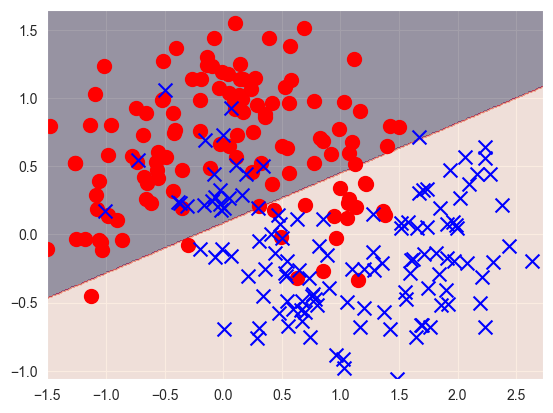

In [199]:
xx, yy = np.meshgrid(
    np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
    np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

### Метрики

In [200]:
print("R2 = ", logistic.score(X, y))
metrics.append(logistic.score(X, y))

R2 =  0.832


### Преобразуем в полином

In [201]:
class_transform = PolynomialFeatures(degree=3, include_bias=False) # Полином со степенью 3
X_3 = class_transform.fit_transform(X) # Трансформируем данные для полинома 3 степени
print(X_3.shape)

(250, 9)


In [202]:
start_time = time.time()  # старт таймера

class_3 = LogisticRegression().fit(X_3, y)

end_time = time.time()    # конец таймера
t_class_poly3 = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_class_poly3, " сек.")

Время обучения модели:  0.003570079803466797  сек.


### Визуализируем полиномиальнуюю модель

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


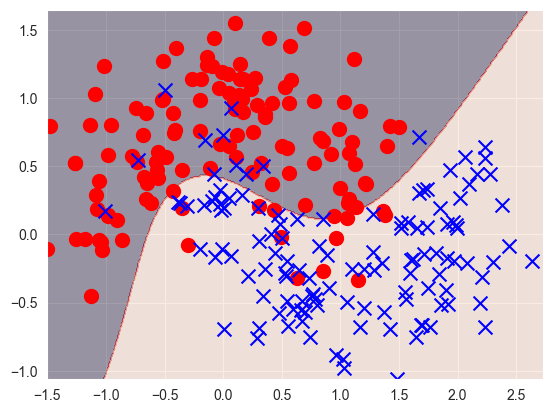

In [203]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

### Метрики

In [204]:
print("R2 = ", class_3.score(X_3, y))
metrics.append(class_3.score(X_3, y))

R2 =  0.9


### Регрессия на реальных данных

In [205]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [206]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Удалим 3 не влияющих на данные столбца для данных и целевую переменную - Цена

In [207]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

### Создадим и обучим модель, выведя точность

In [208]:
start_time = time.time()  # старт таймера

reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)

end_time = time.time()    # конец таймера
t_real_lin = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_real_lin, " сек.")
print()
print("R2 = ", reg_kc_multiple.score(X_kc_prices, y_kc_prices))
metrics.append(reg_kc_multiple.score(X_kc_prices, y_kc_prices))

Время обучения модели:  0.004628896713256836  сек.

R2 =  0.699747189010915


### Визуализируем целевую переменную

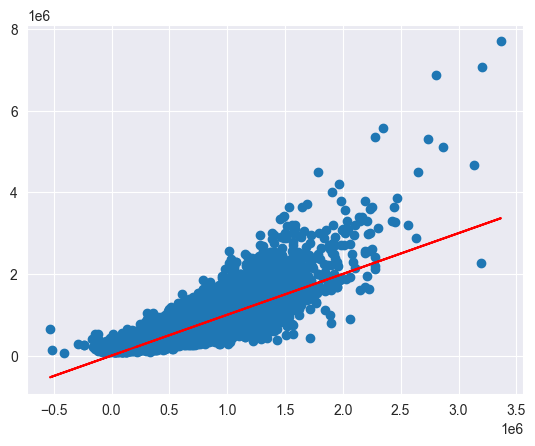

In [209]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

### Трансформируем датасет для полинома

In [210]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices) # 3 степень полинома

X_3_kc_prices.shape

(21613, 1330)

### Обучим полиномиальную модель и выведем точность

In [211]:
start_time = time.time()  # старт таймера

reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)

end_time = time.time()    # конец таймера
t_real_poly2 = end_time - start_time  # разница — время обучения
print("Время обучения модели: ", t_real_poly2, " сек.")
print()
print("R2 = ", reg_poly2_kc.score(X_3_kc_prices, y_kc_prices))
metrics.append(reg_poly2_kc.score(X_3_kc_prices, y_kc_prices))

Время обучения модели:  0.9958591461181641  сек.

R2 =  0.8326020796592419


### Визуализация отклонений

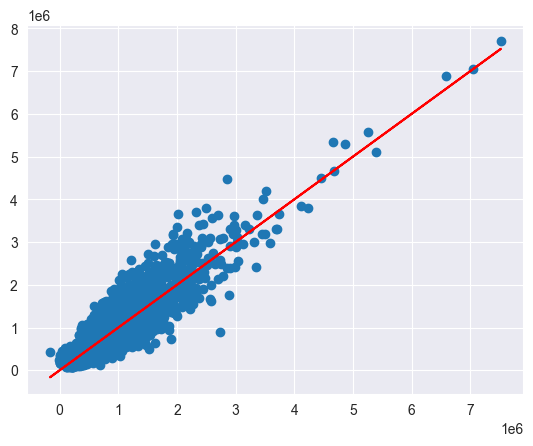

In [212]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

# =======================================================================================

# **Самостоятельные задания**

## 1. Замер времени обучения всех моделей

In [213]:
times = [t_reg_lin, t_reg_poly2, t_class_lin, t_class_poly3, t_real_lin, t_real_poly2]
models = ["Модель LinearRegression", "Модель LinearRegression_poly2", "Модель LogisticRegression", "Модель LogisticRegression_poly3",
          "Модель RealLinearRegression", "Модель RealLinearRegression_poly3"]

q = pd.DataFrame({"Модель": models, "Время обучения": times, "Точность": metrics})
df_sorted = q.sort_values(by='Время обучения', ascending=True)
df_sorted

,Модель,Время обучения,Точность
1,Модель LinearRegression_poly2,0.000927,0.735975
0,Модель LinearRegression,0.001122,0.374674
3,Модель LogisticRegression_poly3,0.003570,0.900000
2,Модель LogisticRegression,0.004100,0.832000
4,Модель RealLinearRegression,0.004629,0.699747
5,Модель RealLinearRegression_poly3,0.995859,0.832602


## 2. Модели 5, 10 и 100-порядков на датасете "gen_regression"

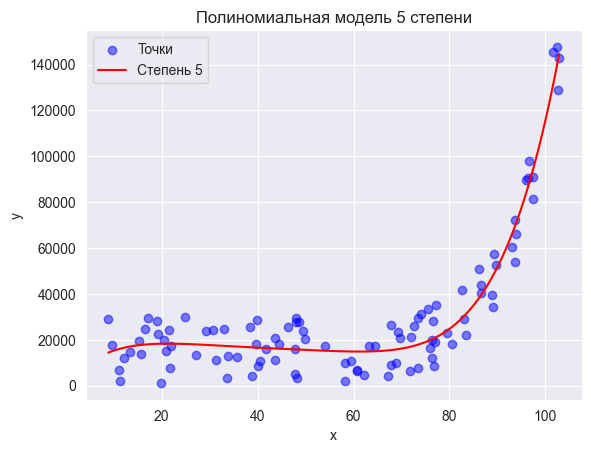

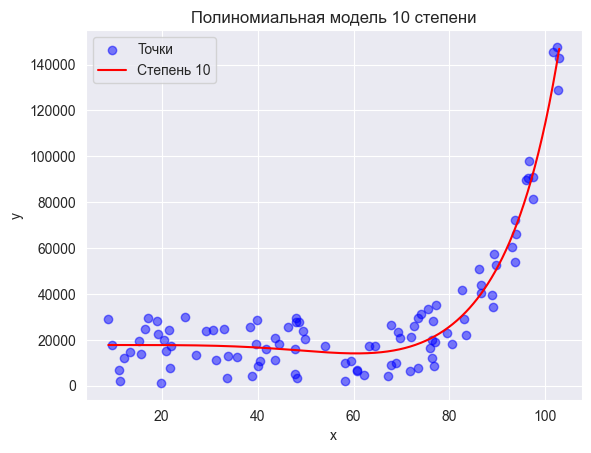

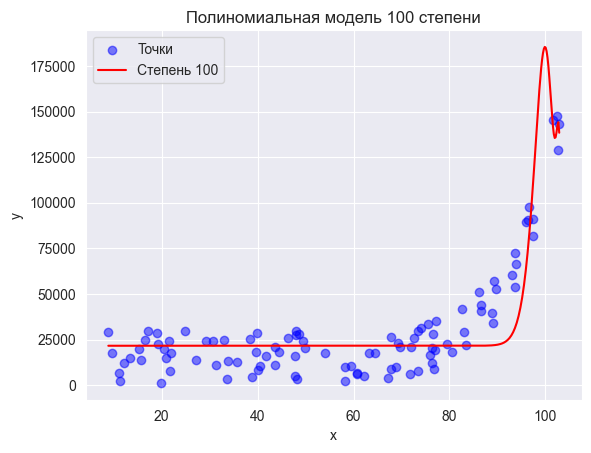

,Модель,Время обучения,Точность
1,Модель полиномиальная 10 степени,0.000364,0.922247
0,Модель полиномиальная 5 степени,0.000318,0.921748
2,Модель полиномиальная 100 степени,0.002355,0.792462


In [214]:
t, acc = [], []

data = pd.read_csv("./data/gen_regression.csv")
X = data.x.values.reshape(-1, 1)  # делаем из Series матрицу
y = data.y.values


def plot_models_on_data(X, y, model, d):
    # Создаем массив для отображения кривых
    min_x, max_x = X.min(), X.max()
    X_plot = np.linspace(min_x, max_x, 500).reshape(-1,1)

    plt.scatter(X, y, color='blue', alpha=0.5, label='Точки')

    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_plot)
    y_pred = model.predict(X_poly)
    plt.plot(X_plot, y_pred, color="red", label=f'Степень {d}')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Полиномиальная модель {d} степени')
    plt.legend()
    plt.show()


def PolyFit(d):
    poly = PolynomialFeatures(degree=d)

    # Преобразуем исходный X
    X_poly = poly.fit_transform(X)

    # Обучаем модель
    model = LinearRegression()
    start_time = time.time()
    model.fit(X_poly, y)
    t = time.time() - start_time
    acc = model.score(X_poly, y)

    plot_models_on_data(X, y, model, d)
    return t, acc


for i in [5, 10, 100]:
    tm, accuracy = PolyFit(i)
    t.append(tm)
    acc.append(accuracy)


models = ["Модель полиномиальная 5 степени", "Модель полиномиальная 10 степени", "Модель полиномиальная 100 степени"]
q = pd.DataFrame({"Модель": models, "Время обучения": t, "Точность": acc})
df_sorted_1 = q.sort_values(by='Точность', ascending=False)
df_sorted_1

## 3. Модели 5, 10 и 100-порядков на датасете "King county"

In [215]:
t, acc = [], []

data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
y = data.price
X = data.drop(["id", "date", "price"], axis=1)


def PolyFit(d):
    poly = PolynomialFeatures(degree=d)

    # Преобразуем исходный X
    X_poly = poly.fit_transform(X)

    # Обучаем модель
    model = LinearRegression()
    start_time = time.time()
    model.fit(X_poly, y)
    t = time.time() - start_time
    acc = model.score(X_poly, y)
    return t, acc


for i in [5, 10, 100]:
    tm, accuracy = PolyFit(i)
    t.append(tm)
    acc.append(accuracy)


models = ["Модель полиномиальная 5 степени", "Модель полиномиальная 10 степени", "Модель полиномиальная 100 степени"]
q = pd.DataFrame({"Модель": models, "Время обучения": t, "Точность": acc})
df_sorted_2 = q.sort_values(by='Точность', ascending=False)
df_sorted_2

MemoryError: Unable to allocate 2.06 TiB for an array with shape (21613, 13123110) and data type float64

### 4. Таблицы эффективноости моделей

In [150]:
print("Таблица эффективности для моделей из теоретической части")
df_sorted

Таблица эффективности для моделей из теоретической части


,Модель,Время обучения,Точность
1,Модель LinearRegression_poly2,0.000634,0.735975
0,Модель LinearRegression,0.000992,0.374674
2,Модель LogisticRegression,0.002396,0.832000
3,Модель LogisticRegression_poly3,0.003902,0.900000
4,Модель RealLinearRegression,0.004800,0.699747
5,Модель RealLinearRegression_poly3,1.060371,0.832602


In [151]:
print("Таблица эффективности для моделей полиномов для датасета 'gen_regression':")
df_sorted_1

Таблица эффективности для моделей полиномов для датасета 'gen_regression':


,Модель,Время обучения,Точность
1,Модель полиномиальная 10 степени,0.000441,0.922247
0,Модель полиномиальная 5 степени,0.000402,0.921748
2,Модель полиномиальная 100 степени,0.004861,0.792462


### 5. Вывод коэффициентов для каждого атрибута на реальном датасете

In [153]:
model_house = LinearRegression().fit(X_kc_prices, y_kc_prices)


c = model_house.coef_
a = list(X_kc_prices.columns)

print("Атрибуты и их коэффициенты и значимость на датасете продажи домов")
print()
for i in range(len(a)):
    print(f"{a[i]:15}:      {c[i]:.3f}")

Атрибуты и их коэффициенты и значимость на датасете продажи домов

bedrooms       :      -35766.541
bathrooms      :      41144.279
sqft_living    :      110.443
sqft_lot       :      0.129
floors         :      6689.550
waterfront     :      582960.458
view           :      52870.942
condition      :      26385.649
grade          :      95890.445
sqft_above     :      70.785
sqft_basement  :      39.658
yr_built       :      -2620.223
yr_renovated   :      19.813
zipcode        :      -582.420
lat            :      602748.226
long           :      -214729.828
sqft_living15  :      21.681
sqft_lot15     :      -0.383


### 6. Интерпретация на полиномиальной модели на реальном датасете

In [154]:
model_house_poly = LinearRegression().fit(X_3_kc_prices, y_kc_prices)


c = model_house_poly.coef_
a = list(X_kc_prices.columns)

print("Атрибуты и их коэффициенты и значимость на датасете продажи домов")
print()
for i in range(len(a)):
    print(f"{a[i]:15}:      {c[i]}")

Атрибуты и их коэффициенты и значимость на датасете продажи домов

bedrooms       :      -1.6335918043411734e-08
bathrooms      :      1.6718762097054396e-07
sqft_living    :      1.0349315209567787e-07
sqft_lot       :      2.2869535369681015e-08
floors         :      2.697840532820239e-07
waterfront     :      1.1299620147928211e-08
view           :      -2.8250687309797644e-08
condition      :      6.224611112937115e-09
grade          :      -6.606112578982855e-10
sqft_above     :      1.5656026969683397e-08
sqft_basement  :      4.3052913415003154e-08
yr_built       :      5.548042382484912e-09
yr_renovated   :      -5.26087832470818e-09
zipcode        :      -5.0257961016780824e-09
lat            :      1.4774110601454654e-09
long           :      -2.2902358789073345e-10
sqft_living15  :      -3.797361544895799e-10
sqft_lot15     :      3.3074728140945405e-08
